In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
methods_names = {
    "dist_linguistic_confidence": "Dist. Ling. Conf.",
    "dist_semantic_uncertainty": "Dist. Semantic Unc.",
    "dist_lnll": "Dist. Token Prob"
}

dataset_size = {
    "mmlu": 116000,
    "squadv2": 130000,
    "truthful_qa": 817
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuAD2.0",
    "truthful_qa": "TruthfulQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
}

# Direct QA

In [3]:
prompt_type = "direct_qa"

In [4]:
if os.path.exists(f"/hdd/ivny/{prompt_type}_in_domain_calibration"):
    results_dir = f"/hdd/ivny/{prompt_type}_in_domain_calibration"

    # list all leaf nodes in results_dir
    leaf_dirs = []
    for root, dirs, files in os.walk(results_dir):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_dirs.append(root)

    all_records_direct = []
    for leaf_dir in leaf_dirs:
        _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
        if os.path.exists(os.path.join(leaf_dir, "calibration_performance.csv")):
            csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_performance.csv"), index_col=0)
            csv_records = csv_data.transpose().to_dict("records")

            for record in csv_records:
                record["dataset"] = dataset_map.get(dataset_name, dataset_name)
                record["model"] = model_name_map.get(model_name, model_name)
                record["dataset_size"] = dataset_size.get(dataset_name, None)

            all_records_direct.extend(csv_records)
        else:
            print(model_name, dataset_name, "missing calibration_performance.csv")
else:
    results_dir = f"/home/ivan/lm-confidence-evaluation-harness/ivny/{prompt_type}_in_domain_calibration"
    
    # list all leaf nodes in results_dir
    leaf_dirs = []
    for root, dirs, files in os.walk(results_dir):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_dirs.append(root)

    all_records_direct = []
    for leaf_dir in leaf_dirs:
        _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
        if os.path.exists(os.path.join(leaf_dir, "calibration_performance.csv")):
            csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_performance.csv"), index_col=0)
            csv_records = csv_data.transpose().to_dict("records")

            for record in csv_records:
                record["dataset"] = dataset_map.get(dataset_name, dataset_name)
                record["model"] = model_name_map.get(model_name, model_name)
                record["dataset_size"] = dataset_size.get(dataset_name, None)

            all_records_direct.extend(csv_records)
        else:
            print(model_name, dataset_name, "missing calibration_performance.csv")

In [5]:
# mean_df = pd.DataFrame(all_records).drop(columns=["dataset"]).groupby(["model"]).mean().reset_index()
# mean_df

df = pd.DataFrame(all_records_direct).drop(columns=["dataset"])

group_cols = ["model"]
weight_col = "dataset_size"
metric_cols = [c for c in df.columns if c not in group_cols + [weight_col]]

def weighted_avg_by_group(group):
    weights = pd.to_numeric(group[weight_col], errors="coerce").fillna(0)
    out = {}
    for col in metric_cols:
        values = pd.to_numeric(group[col], errors="coerce")
        mask = values.notna() & (weights > 0)
        if mask.any():
            out[col] = np.average(values[mask], weights=weights[mask])
        else:
            out[col] = values.mean()
    return pd.Series(out)

dataset_weighted_average_mean = (
    df.groupby(group_cols)
    .apply(weighted_avg_by_group)
    .reset_index()
)

dataset_weighted_average_mean

,model,original_lc_generalised_ECE,original_lc_faithfulness_divergence,original_lc_ece_mean,original_lc_dAUROC,original_lc_auroc_mean,original_tp_generalised_ECE,original_tp_faithfulness_divergence,original_tp_ece_mean,original_tp_dAUROC,...,calibrated_su_rewritten_lc_generalised_ECE,calibrated_su_rewritten_lc_faithfulness_divergence,calibrated_su_rewritten_lc_ece_mean,calibrated_su_rewritten_lc_dAUROC,calibrated_su_rewritten_lc_auroc_mean,calibrated_su_beta_guided_lc_generalised_ECE,calibrated_su_beta_guided_lc_faithfulness_divergence,calibrated_su_beta_guided_lc_ece_mean,calibrated_su_beta_guided_lc_dAUROC,calibrated_su_beta_guided_lc_auroc_mean
0,GPT-OSS-20B,0.277496,1.472587,0.235994,0.508565,0.505802,0.215273,1.377133,0.189932,0.564103,...,0.114516,0.704376,0.103600,0.670591,0.696067,0.173183,0.745216,0.151057,0.570133,0.590750
1,Llama-3.1-8B-Inst.,0.251591,1.280265,0.210116,0.534427,0.543703,0.220941,2.943417,0.209530,0.651293,...,0.108025,0.571482,0.088026,0.639382,0.678086,0.141983,0.713628,0.131070,0.564332,0.594440
2,Mistral-7B-Inst.,0.298302,1.610928,0.271704,0.506678,0.503897,0.331278,159.977665,0.329564,0.630860,...,0.114870,0.576941,0.096068,0.540853,0.553150,0.181772,0.797122,0.178489,0.517141,0.524826
3,Qwen3-8B-Inst.,0.274596,1.538303,0.227096,0.533431,0.541527,0.372578,204.820376,0.370441,0.576911,...,0.161632,0.750108,0.144814,0.560921,0.583592,0.178500,0.795816,0.165379,0.524709,0.536517


In [6]:
# calibrated beta guided FD
dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_beta_guided_lc_faithfulness_divergence", "calibrated_tp_beta_guided_lc_faithfulness_divergence", "calibrated_su_beta_guided_lc_faithfulness_divergence"]].mean()

np.float64(0.7864477099771289)

In [7]:
# calibrated beta guided ECE 
dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_beta_guided_lc_generalised_ECE", "calibrated_tp_beta_guided_lc_generalised_ECE", "calibrated_su_beta_guided_lc_generalised_ECE"]].mean()

np.float64(0.17527898520316906)

In [8]:
# calibrated FD
dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_rewritten_lc_faithfulness_divergence", "calibrated_tp_rewritten_lc_faithfulness_divergence", "calibrated_su_rewritten_lc_faithfulness_divergence"]].mean()

np.float64(0.7052425354568822)

In [9]:
# calibrated ECE
dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_rewritten_lc_generalised_ECE", "calibrated_tp_rewritten_lc_generalised_ECE", "calibrated_su_rewritten_lc_generalised_ECE"]].mean()

np.float64(0.14638599257359516)

In [10]:
# original FD
dataset_weighted_average_mean.drop(columns=["model"]).mean()["original_lc_faithfulness_divergence"]

np.float64(1.4755207557320844)

In [11]:
# original ECE
dataset_weighted_average_mean.drop(columns=["model"]).mean()["original_lc_generalised_ECE"]

np.float64(0.2754962259819099)

# Hedged QA

In [12]:
prompt_type = "hedged_qa"

In [13]:
common_path = "/hdd/ivny/results"
if os.path.exists(common_path):
    results_dir = common_path
else:
    results_dir = f"/home/ivan/lm-confidence-evaluation-harness/ivny/results"

mmlu_path = os.path.join(results_dir, "mmlu/hedged_qa_unified_lc")
squadv2_path = os.path.join(results_dir, "squadv2/hedged_qa_unified_lc")
truthfulqa_path = os.path.join(results_dir, "truthful_qa/hedged_qa_unified_lc")

In [14]:
def get_latest_subdir(path):
    subdirs = [os.path.join(path, d) for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    return max(subdirs, key=os.path.getmtime) if subdirs else None

results_dir = "/hdd/ivny/results" if os.path.exists("/hdd/ivny") else "/home/ivan/lm-confidence-evaluation-harness/ivny/results"

paths = {
    "mmlu":        os.path.join(results_dir, "mmlu",        f"{prompt_type}_unified_lc"),
    "squadv2":     os.path.join(results_dir, "squadv2",     f"{prompt_type}_unified_lc"),
    "truthful_qa": os.path.join(results_dir, "truthful_qa", f"{prompt_type}_unified_lc"),
}

all_records_hedged = []
for dataset_name, path in paths.items():
    if not os.path.exists(path):
        print(f"Missing: {path}")
        continue
    seen_models = {}  # model_name -> (latest_dir, latest_mtime)
    for org in os.listdir(path):
        org_path = os.path.join(path, org)
        if not os.path.isdir(org_path):
            continue
        for model_name in os.listdir(org_path):
            model_path = os.path.join(org_path, model_name)
            if not os.path.isdir(model_path):
                continue
            latest = get_latest_subdir(model_path)
            if latest is None:
                continue
            mtime = os.path.getmtime(latest)
            if model_name not in seen_models or mtime > seen_models[model_name][1]:
                seen_models[model_name] = (latest, mtime)

    for model_name, (latest_dir, _) in seen_models.items():
        csv_path = os.path.join(latest_dir, "eval_metrics.csv")
        if not os.path.exists(csv_path):
            print(f"Missing eval_metrics.csv: {latest_dir}")
            continue
        try:
            row = pd.read_csv(csv_path).iloc[0]
            all_records_hedged.append({
                "model":                  model_name_map.get(model_name, model_name),
                "dataset":                dataset_map.get(dataset_name, dataset_name),
                "dataset_size":           dataset_size.get(dataset_name, None),
                "generalised_ECE":        row["generalised_ece"],
                "faithfulness_divergence": row["faithfulness_divergence"],
            })
        except Exception as e:
            print(f"Error processing {csv_path}: {e}")


Error processing /hdd/ivny/results/mmlu/hedged_qa_unified_lc/openai/gpt-oss-120b/2026-04-19_03-27-57/eval_metrics.csv: No columns to parse from file
Missing eval_metrics.csv: /hdd/ivny/results/mmlu/hedged_qa_unified_lc/google/gemma-4-31B-it/2026-04-19_23-55-11
Missing eval_metrics.csv: /hdd/ivny/results/mmlu/hedged_qa_unified_lc/meta-llama/Llama-3.3-70B-Instruct-Turbo/2026-04-19_03-27-57
Error processing /hdd/ivny/results/mmlu/hedged_qa_unified_lc/qwen/Qwen3-235B-A22B-Instruct-2507-tput/2026-04-19_03-27-57/eval_metrics.csv: No columns to parse from file
Error processing /hdd/ivny/results/squadv2/hedged_qa_unified_lc/openai/gpt-oss-120b/2026-04-19_03-30-46/eval_metrics.csv: No columns to parse from file
Missing eval_metrics.csv: /hdd/ivny/results/squadv2/hedged_qa_unified_lc/google/gemma-4-31B-it/2026-04-19_23-56-21
Error processing /hdd/ivny/results/squadv2/hedged_qa_unified_lc/meta-llama/Llama-3.3-70B-Instruct-Turbo/2026-04-19_03-30-46/eval_metrics.csv: No columns to parse from file
E

In [15]:
df_hedged = pd.DataFrame(all_records_hedged)
weights = pd.to_numeric(df_hedged["dataset_size"], errors="coerce").fillna(0)
hedged_qa_metrics = {
    col: np.average(pd.to_numeric(df_hedged[col], errors="coerce").fillna(0), weights=weights)
    for col in ["generalised_ECE", "faithfulness_divergence"]
}
hedged_qa_metrics

{'generalised_ECE': np.float64(0.26626665822807705),
 'faithfulness_divergence': np.float64(1.5479948104601111)}

# Entailment Scores

In [119]:
results_dir = f"/hdd/ivny/results/"


def get_leaf_nodes(path):
    leaf_nodes = []
    for root, dirs, files in os.walk(path):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_nodes.append(root)
    return leaf_nodes

leaf_dirs = get_leaf_nodes(results_dir)

direct_qa_leafs = sorted([leaf for leaf in leaf_dirs if "direct_qa_unified_lc" in leaf])   
direct_qa_leafs

['/hdd/ivny/results/mmlu/direct_qa_unified_lc/google/gemma-4-31B-it/2026-04-19_23-58-16',
 '/hdd/ivny/results/mmlu/direct_qa_unified_lc/meta-llama/Llama-3.1-8B-Instruct/2026-04-20_02-18-39',
 '/hdd/ivny/results/mmlu/direct_qa_unified_lc/meta-llama/Llama-3.3-70B-Instruct-Turbo/2026-04-19_03-27-05',
 '/hdd/ivny/results/mmlu/direct_qa_unified_lc/mistralai/Mistral-7B-Instruct-v0.3/2026-04-20_05-13-18',
 '/hdd/ivny/results/mmlu/direct_qa_unified_lc/openai/gpt-oss-120b/2026-04-19_03-27-05',
 '/hdd/ivny/results/mmlu/direct_qa_unified_lc/openai/gpt-oss-20b/2026-04-20_00-51-39',
 '/hdd/ivny/results/mmlu/direct_qa_unified_lc/qwen/Qwen3-235B-A22B-Instruct-2507-tput/2026-04-19_03-27-05',
 '/hdd/ivny/results/mmlu/direct_qa_unified_lc/qwen/Qwen3-8B/2026-04-20_03-46-02',
 '/hdd/ivny/results/squadv2/direct_qa_unified_lc/google/gemma-4-31B-it/2026-04-19_23-55-37',
 '/hdd/ivny/results/squadv2/direct_qa_unified_lc/meta-llama/Llama-3.1-8B-Instruct/2026-04-20_02-08-08',
 '/hdd/ivny/results/squadv2/direct_q

In [120]:
hedged_qa_leafs = sorted([leaf for leaf in leaf_dirs if "hedged_qa_unified_lc" in leaf])
hedged_qa_leafs

['/hdd/ivny/results/mmlu/hedged_qa_unified_lc/google/gemma-4-31B-it/2026-04-19_23-55-11',
 '/hdd/ivny/results/mmlu/hedged_qa_unified_lc/meta-llama/Llama-3.1-8B-Instruct/2026-04-20_08-16-53',
 '/hdd/ivny/results/mmlu/hedged_qa_unified_lc/meta-llama/Llama-3.3-70B-Instruct-Turbo/2026-04-19_03-27-57',
 '/hdd/ivny/results/mmlu/hedged_qa_unified_lc/mistralai/Mistral-7B-Instruct-v0.3/2026-04-20_12-10-14',
 '/hdd/ivny/results/mmlu/hedged_qa_unified_lc/openai/gpt-oss-120b/2026-04-19_03-27-57',
 '/hdd/ivny/results/mmlu/hedged_qa_unified_lc/openai/gpt-oss-20b/2026-04-20_06-44-08',
 '/hdd/ivny/results/mmlu/hedged_qa_unified_lc/qwen/Qwen3-235B-A22B-Instruct-2507-tput/2026-04-19_03-27-57',
 '/hdd/ivny/results/mmlu/hedged_qa_unified_lc/qwen/Qwen3-8B/2026-04-20_10-33-26',
 '/hdd/ivny/results/squadv2/hedged_qa_unified_lc/google/gemma-4-31B-it/2026-04-19_23-56-21',
 '/hdd/ivny/results/squadv2/hedged_qa_unified_lc/meta-llama/Llama-3.1-8B-Instruct/2026-04-20_05-36-53',
 '/hdd/ivny/results/squadv2/hedged_q

In [121]:
len(hedged_qa_leafs), len(direct_qa_leafs)

(24, 24)

In [122]:
direct_responses = []
hedged_responses = []

for direct, hedged in zip(direct_qa_leafs, hedged_qa_leafs):
    try:
        direct_details = pd.read_csv(os.path.join(direct, "eval_details.csv"))
        hedged_details = pd.read_csv(os.path.join(hedged, "eval_details.csv"))
        direct_responses.extend(direct_details["response_0"].tolist())
        hedged_responses.extend(hedged_details["response_0"].tolist())
    except Exception as e:
        print(f"Error processing {direct} or {hedged}: {e}")

Error processing /hdd/ivny/results/mmlu/direct_qa_unified_lc/google/gemma-4-31B-it/2026-04-19_23-58-16 or /hdd/ivny/results/mmlu/hedged_qa_unified_lc/google/gemma-4-31B-it/2026-04-19_23-55-11: [Errno 2] No such file or directory: '/hdd/ivny/results/mmlu/direct_qa_unified_lc/google/gemma-4-31B-it/2026-04-19_23-58-16/eval_details.csv'
Error processing /hdd/ivny/results/mmlu/direct_qa_unified_lc/meta-llama/Llama-3.3-70B-Instruct-Turbo/2026-04-19_03-27-05 or /hdd/ivny/results/mmlu/hedged_qa_unified_lc/meta-llama/Llama-3.3-70B-Instruct-Turbo/2026-04-19_03-27-57: [Errno 2] No such file or directory: '/hdd/ivny/results/mmlu/hedged_qa_unified_lc/meta-llama/Llama-3.3-70B-Instruct-Turbo/2026-04-19_03-27-57/eval_details.csv'
Error processing /hdd/ivny/results/mmlu/direct_qa_unified_lc/openai/gpt-oss-120b/2026-04-19_03-27-05 or /hdd/ivny/results/mmlu/hedged_qa_unified_lc/openai/gpt-oss-120b/2026-04-19_03-27-57: 'response_0'
Error processing /hdd/ivny/results/mmlu/direct_qa_unified_lc/qwen/Qwen3-23

In [123]:
# Compute NLI scores
from sentence_transformers import CrossEncoder
import scipy.special as sp

# ---- Your data ----
list1 = direct_responses   # original (x1)
list2 = hedged_responses  # rewritten (x2)

# # ---- Sample at most 10000 pairs ----
# max_samples = 10000
# if len(list1) > max_samples:
#     rng = np.random.default_rng(42)
#     indices = rng.choice(len(list1), size=max_samples, replace=False)
#     list1 = [list1[i] for i in indices]
#     list2 = [list2[i] for i in indices]

# ---- Load NLI model (DeBERTa) ----
model = CrossEncoder("cross-encoder/nli-deberta-v3-base")

# ---- Direction: rewrite -> original ----
pairs_21 = [(str(x2), str(x1)) for x1, x2 in zip(list1, list2)]


logits_21 = model.predict(
    pairs_21,
    batch_size=128,
    show_progress_bar=True
)

probs_21 = sp.softmax(logits_21, axis=1)

# NLI label order: [contradiction, entailment, neutral]
entail_21 = probs_21[:, 1]
neutral_21 = probs_21[:, 2]

# ---- Soft entailment (lenient) ----
direct_vs_hedged_entailment_scores = entail_21 + 0.5 * neutral_21
direct_vs_hedged_entailment_scores

Batches: 100%|██████████| 836/836 [04:54<00:00,  2.83it/s]


Batches: 100%|██████████| 836/836 [04:54<00:00,  2.83it/s]


array([5.6807809e-03, 6.9430154e-03, 1.0501628e-03, ..., 4.9998483e-01,
       9.5410105e-05, 2.7319229e-05], shape=(106928,), dtype=float32)

In [92]:
prompt_type = "direct_qa"
if os.path.exists(f"/hdd/ivny/{prompt_type}_in_domain_calibration"):
    results_dir = f"/hdd/ivny/{prompt_type}_in_domain_calibration"

    # list all leaf nodes in results_dir
    leaf_dirs = []
    for root, dirs, files in os.walk(results_dir):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_dirs.append(root)

    all_records_direct = []
    for leaf_dir in leaf_dirs:
        _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
        if os.path.exists(os.path.join(leaf_dir, "calibration_details.csv")):
            csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_details.csv"))
            csv_records = csv_data.to_dict("records")
            all_records_direct.extend(csv_records)
        else:
            print(model_name, dataset_name, "missing calibration_details.csv")
else:
    results_dir = f"/home/ivan/lm-confidence-evaluation-harness/ivny/{prompt_type}_in_domain_calibration"
    
    # list all leaf nodes in results_dir
    leaf_dirs = []
    for root, dirs, files in os.walk(results_dir):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_dirs.append(root)

    all_records_direct = []
    for leaf_dir in leaf_dirs:
        _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
        if os.path.exists(os.path.join(leaf_dir, "calibration_details.csv")):
            csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_details.csv"))
            csv_records = csv_data.to_dict("records")
            all_records_direct.extend(csv_records)
        else:
            print(model_name, dataset_name, "missing calibration_details.csv")

In [97]:
eval_detailes_df = pd.DataFrame(all_records_direct)
original_responses = eval_detailes_df["original_response"].tolist()

calibrated_lc_rewritten_responses = eval_detailes_df["calibrated_lc_rewritten_response"].tolist()
calibrated_tp_rewritten_responses = eval_detailes_df["calibrated_tp_rewritten_response"].tolist()
calibrated_su_rewritten_responses = eval_detailes_df["calibrated_su_rewritten_response"].tolist()

calibrated_lc_beta_guided_responses = eval_detailes_df["calibrated_lc_beta_guided_response"].tolist()
calibrated_tp_beta_guided_responses = eval_detailes_df["calibrated_tp_beta_guided_response"].tolist()
calibrated_su_beta_guided_responses = eval_detailes_df["calibrated_su_beta_guided_response"].tolist()


In [98]:
# Entailment: pair each calibrated response with the original response
import scipy.special as sp

if "model" not in globals():
    from sentence_transformers import CrossEncoder
    model = CrossEncoder("cross-encoder/nli-deberta-v3-base")

def entailment_against_original(original_list, rewritten_list, nli_model, batch_size=128):
    pairs = [(str(rewritten), str(original)) for original, rewritten in zip(original_list, rewritten_list)]
    logits = nli_model.predict(
        pairs,
        batch_size=batch_size,
        show_progress_bar=True,
    )
    probs = sp.softmax(logits, axis=1)
    entail = probs[:, 1]
    neutral = probs[:, 2]
    # Soft entailment score used elsewhere in this notebook
    return entail + 0.5 * neutral

response_variants = {
    "calibrated_lc_rewritten": calibrated_lc_rewritten_responses,
    "calibrated_tp_rewritten": calibrated_tp_rewritten_responses,
    "calibrated_su_rewritten": calibrated_su_rewritten_responses,
    "calibrated_lc_beta_guided": calibrated_lc_beta_guided_responses,
    "calibrated_tp_beta_guided": calibrated_tp_beta_guided_responses,
    "calibrated_su_beta_guided": calibrated_su_beta_guided_responses,
}

entailment_scores_by_variant = {
    name: entailment_against_original(original_responses, responses, model)
    for name, responses in response_variants.items()
}

mean_entailment_by_variant = {
    name: float(np.mean(scores))
    for name, scores in entailment_scores_by_variant.items()
}

mean_entailment_by_variant

Batches: 100%|██████████| 585/585 [01:47<00:00,  5.44it/s]


Batches: 100%|██████████| 585/585 [01:47<00:00,  5.44it/s]


{'calibrated_lc_rewritten': 0.9552075862884521,
 'calibrated_tp_rewritten': 0.950683057308197,
 'calibrated_su_rewritten': 0.9494592547416687,
 'calibrated_lc_beta_guided': 0.9567964673042297,
 'calibrated_tp_beta_guided': 0.9563066959381104,
 'calibrated_su_beta_guided': 0.9560889005661011}

In [133]:
mean_entailment_by_variant = {
    name: scores
    for name, scores in entailment_scores_by_variant.items()
}

# Plot

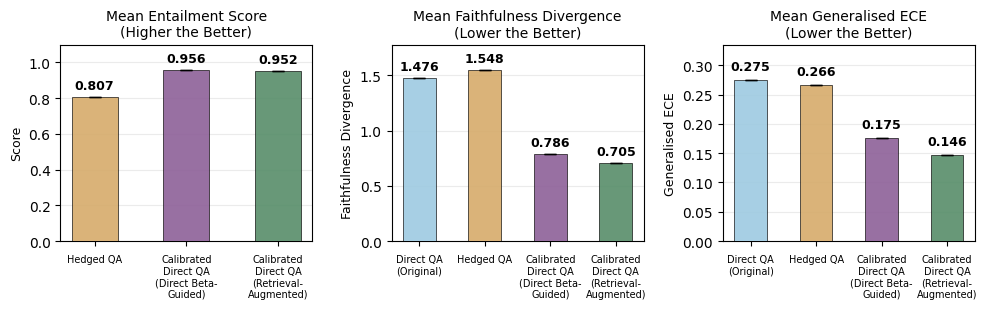

In [16]:
import matplotlib.pyplot as plt

# Values taken from the summary above
# entailment_scores = {
#     "Hedged QA": np.mean(direct_vs_hedged_entailment_scores),
#     "Calibrated\nDirect QA\n(Raw Beta-\nGuided)": np.mean(mean_entailment_by_variant["calibrated_lc_beta_guided"].tolist() + mean_entailment_by_variant["calibrated_tp_beta_guided"].tolist() + mean_entailment_by_variant["calibrated_su_beta_guided"].tolist()),
#     "Calibrated\nDirect QA\n(Retrieval-\nAugmented)": np.mean(mean_entailment_by_variant["calibrated_lc_rewritten"].tolist() + mean_entailment_by_variant["calibrated_tp_rewritten"].tolist() + mean_entailment_by_variant["calibrated_su_rewritten"].tolist()),
# }

entailment_scores = {
    "Hedged QA": 0.807,
    "Calibrated\nDirect QA\n(Direct Beta-\nGuided)": 0.956,
    "Calibrated\nDirect QA\n(Retrieval-\nAugmented)": 0.952,
}

faithfulness_divergence = {
    "Direct QA\n(Original)": dataset_weighted_average_mean.drop(columns=["model"]).mean()["original_lc_faithfulness_divergence"],
    "Hedged QA": hedged_qa_metrics["faithfulness_divergence"],
    "Calibrated\nDirect QA\n(Direct Beta-\nGuided)": dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_beta_guided_lc_faithfulness_divergence", "calibrated_tp_beta_guided_lc_faithfulness_divergence", "calibrated_su_beta_guided_lc_faithfulness_divergence"]].mean(),
    "Calibrated\nDirect QA\n(Retrieval-\nAugmented)": dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_rewritten_lc_faithfulness_divergence", "calibrated_tp_rewritten_lc_faithfulness_divergence", "calibrated_su_rewritten_lc_faithfulness_divergence"]].mean(),
}

generalised_ece = {
    "Direct QA\n(Original)": dataset_weighted_average_mean.drop(columns=["model"]).mean()["original_lc_generalised_ECE"],
    "Hedged QA": hedged_qa_metrics["generalised_ECE"],
    "Calibrated\nDirect QA\n(Direct Beta-\nGuided)": dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_beta_guided_lc_generalised_ECE", "calibrated_tp_beta_guided_lc_generalised_ECE", "calibrated_su_beta_guided_lc_generalised_ECE"]].mean(),
    "Calibrated\nDirect QA\n(Retrieval-\nAugmented)": dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_rewritten_lc_generalised_ECE", "calibrated_tp_rewritten_lc_generalised_ECE", "calibrated_su_rewritten_lc_generalised_ECE"]].mean(),
}

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))

def annotate_bars(ax, bars, decimals=3):
    heights = [bar.get_height() for bar in bars]
    y_max = max(heights) if heights else 0
    y_offset = max(y_max * 0.03, 0.012)

    current_bottom, current_top = ax.get_ylim()
    target_top = y_max + y_offset * 5.0
    if target_top > current_top:
        ax.set_ylim(current_bottom, target_top)

    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + y_offset,
            f"{h:.{decimals}f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            clip_on=True,
        )

# LEFT: Mean entailment score — 3 bars
bars0 = axes[0].bar(
    list(entailment_scores.keys()),
    list(entailment_scores.values()),
    color=["#D6AB6B", "#8D6098", "#578D69"],
    edgecolor="black",
    linewidth=0.5,
    alpha=0.9,
    width=0.5,
    zorder=3,
    capsize=4,
    yerr=[0.0, 0.0, 0.0],
)
axes[0].set_title("Mean Entailment Score\n(Higher the Better)", fontsize=10)
axes[0].set_ylabel("Score", fontsize=9)
axes[0].grid(axis="y", alpha=0.25, zorder=0)
axes[0].tick_params(axis="x", labelsize=7, pad=6)
annotate_bars(axes[0], bars0, decimals=3)

# MIDDLE: Mean faithfulness divergence — 4 bars
bars1 = axes[1].bar(
    list(faithfulness_divergence.keys()),
    list(faithfulness_divergence.values()),
    color=["#9ECAE1", "#D6AB6B", "#8D6098", "#578D69"],
    edgecolor="black",
    linewidth=0.5,
    alpha=0.9,
    width=0.5,
    zorder=3,
    capsize=4,
    yerr=[0.0, 0.0, 0.0, 0.0],
)
axes[1].set_title("Mean Faithfulness Divergence\n(Lower the Better)", fontsize=10)
axes[1].set_ylabel("Faithfulness Divergence", fontsize=9)
axes[1].grid(axis="y", alpha=0.25, zorder=0)
axes[1].tick_params(axis="x", labelsize=7, pad=6)
annotate_bars(axes[1], bars1, decimals=3)

# RIGHT: Mean generalised ECE — 4 bars
bars2 = axes[2].bar(
    list(generalised_ece.keys()),
    list(generalised_ece.values()),
    color=["#9ECAE1", "#D6AB6B", "#8D6098", "#578D69"],
    edgecolor="black",
    linewidth=0.5,
    alpha=0.9,
    width=0.5,
    zorder=3,
    capsize=4,
    yerr=[0.0, 0.0, 0.0, 0.0],
)
axes[2].set_title("Mean Generalised ECE\n(Lower the Better)", fontsize=10)
axes[2].set_ylabel("Generalised ECE", fontsize=9)
axes[2].grid(axis="y", alpha=0.25, zorder=0)
axes[2].tick_params(axis="x", labelsize=7, pad=6)
annotate_bars(axes[2], bars2, decimals=3)

for ax in axes:
    for label in ax.get_xticklabels():
        label.set_rotation(0)
        label.set_ha("center")

fig.tight_layout()
plt.savefig("figs/calibration_performance_baselines_comparison.pdf", dpi=300, bbox_inches="tight")